In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
brands = pd.read_csv('E:\TRIPLETEN\ecommerce_brands.csv')

In [3]:
brands.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        2000 non-null   object 
 1   product_name      2000 non-null   object 
 2   brand             2000 non-null   object 
 3   category          2000 non-null   object 
 4   subcategory       2000 non-null   object 
 5   price             2000 non-null   int64  
 6   currency          2000 non-null   object 
 7   discount_percent  2000 non-null   int64  
 8   discounted_price  2000 non-null   float64
 9   rating            2000 non-null   float64
 10  reviews_count     2000 non-null   int64  
 11  popularity_score  2000 non-null   float64
 12  stock_status      2000 non-null   object 
 13  date_added        2000 non-null   object 
 14  description       2000 non-null   object 
dtypes: float64(3), int64(3), object(9)
memory usage: 234.5+ KB


In [4]:
brands.head(2)

,product_id,product_name,brand,category,subcategory,price,currency,discount_percent,discounted_price,rating,reviews_count,popularity_score,stock_status,date_added,description
0,P100000,iPhone 13,Apple,Electronics,Smartphone,65372,INR,57,28109.96,3.7,3050,11285.0,Limited Stock,2025-10-17,Apple iPhone 13 is a premium smartphone design...
1,P100001,Zara Shirt,Zara,Fashion,Shirt,2616,INR,55,1177.20,4.1,4699,19265.9,Out of Stock,2026-03-22,Zara Zara Shirt is a premium shirt designed fo...


In [5]:
brands.drop('product_id', axis=1, inplace=True)

In [6]:
brands.head(2)

,product_name,brand,category,subcategory,price,currency,discount_percent,discounted_price,rating,reviews_count,popularity_score,stock_status,date_added,description
0,iPhone 13,Apple,Electronics,Smartphone,65372,INR,57,28109.96,3.7,3050,11285.0,Limited Stock,2025-10-17,Apple iPhone 13 is a premium smartphone design...
1,Zara Shirt,Zara,Fashion,Shirt,2616,INR,55,1177.20,4.1,4699,19265.9,Out of Stock,2026-03-22,Zara Zara Shirt is a premium shirt designed fo...


In [7]:
brands['brand'].value_counts()

brand
Puma                  206
Adidas                203
Nike                  191
Wildcraft             146
RayBan                137
American Tourister    129
Fossil                128
Reebok                116
Apple                  83
H&M                    82
Zara                   78
OnePlus                77
Levi's                 77
Samsung                74
Sony                   73
Boat                   70
Dell                   66
HP                     64
Name: count, dtype: int64

In [8]:
pv = brands.pivot_table(values='product_name', 
                        index=['brand','category','subcategory'],
                        aggfunc='count',
                        fill_value=0,
                        margins=True,
                        margins_name='Total')
pv

product_name
brand              category    subcategory                 
Adidas             Fashion     Hoodie                    71
                   Footwear    Running Shoes            132
American Tourister Accessories Travel Bag               129
Apple              Electronics Smartphone                83
Boat               Electronics Earbuds                   70
Dell               Electronics Laptop                    66
Fossil             Accessories Watch                    128
H&M                Fashion     Sweatshirt                82
HP                 Electronics Laptop                    64
Levi's             Fashion     Jeans                     77
Nike               Fashion     T-shirt                   71
                   Footwear    Sneakers                 120
OnePlus            Electronics Smartphone                77
Puma               Fashion     Jacket                    84
                   Footwear    Sneakers                 122
RayBan             Accessories Sunglasses               137
Reebok             Footwear    Training Shoes           116
Samsung            Electronics Smartphone                74
Sony               Electronics Headphones                73
Wildcraft          Accessories Backpack                 146
Zara               Fashion     Shirt                     78
Total                                                  2000

In [9]:
pv2 = brands.pivot_table(values='brand',
                         index=['product_name','category','subcategory'],
                         aggfunc='count',
                         fill_value=0,
                         margins=True,
                         margins_name='Total')
pv2.sort_values(by='brand')

,,,brand
product_name,category,subcategory,
HP Pavilion,Electronics,Laptop,64
Dell Laptop,Electronics,Laptop,66
Boat Earbuds,Electronics,Earbuds,70
Adidas Hoodie,Fashion,Hoodie,71
Nike T-shirt,Fashion,T-shirt,71
Sony Headphones,Electronics,Headphones,73
Samsung Galaxy S21,Electronics,Smartphone,74
Levi's Jeans,Fashion,Jeans,77
OnePlus 11,Electronics,Smartphone,77


In [10]:
brands['popularity_score'].value_counts().sort_values()

popularity_score
10732.0    1
23422.0    1
11093.6    1
16808.4    1
17401.8    1
          ..
4753.0     2
14125.5    2
19634.9    2
595.7      2
11285.0    2
Name: count, Length: 1962, dtype: int64

In [11]:
brands.columns

Index(['product_name', 'brand', 'category', 'subcategory', 'price', 'currency',
       'discount_percent', 'discounted_price', 'rating', 'reviews_count',
       'popularity_score', 'stock_status', 'date_added', 'description'],
      dtype='object')

In [12]:
brands['currency']

0       INR
1       INR
2       INR
3       INR
4       INR
       ... 
1995    INR
1996    INR
1997    INR
1998    INR
1999    INR
Name: currency, Length: 2000, dtype: object

In [13]:
#Agrupamos popularidad promedio por categoria y subcategoria
sumario = brands.groupby(['category', 'subcategory'])['popularity_score'].mean().reset_index()

In [14]:
pop_sum = sumario.sort_values(by='popularity_score', ascending=False)
pop_sum

,category,subcategory,popularity_score
11,Fashion,Shirt,11626.623077
10,Fashion,Jeans,11191.687013
0,Accessories,Backpack,11044.129452
12,Fashion,Sweatshirt,10735.302439
7,Electronics,Smartphone,10713.558547
6,Electronics,Laptop,10686.716154
2,Accessories,Travel Bag,10680.587597
8,Fashion,Hoodie,10655.740845
16,Footwear,Training Shoes,10361.415517
5,Electronics,Headphones,10207.612329


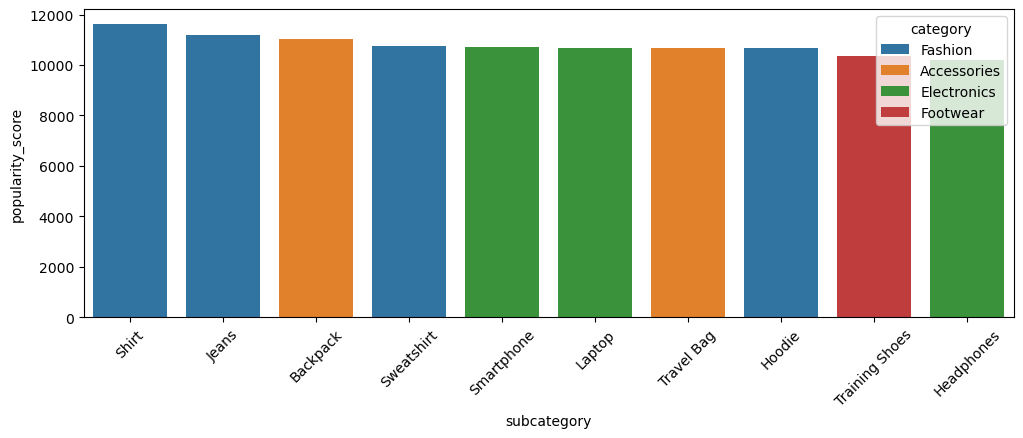

In [15]:
plt.figure(figsize=(12,4))
sns.barplot(data=pop_sum.head(10),x='subcategory', y='popularity_score', hue='category')
plt.xticks(rotation=45)
plt.show()

In [16]:
#Agrupamos por totales con respecto a cada categoria y subcategoria
tendencia = brands.groupby(['category', 'subcategory','brand']).agg({'popularity_score':'mean',
                                                             'discount_percent':'mean',
                                                             'rating':'mean',
                                                             'stock_status':'count'}).reset_index()
mas_popular = tendencia.sort_values(by='popularity_score', ascending=False)

In [17]:
mas_popular.head()

,category,subcategory,brand,popularity_score,discount_percent,rating,stock_status
14,Fashion,Shirt,Zara,11626.623077,39.743590,4.075641,78
13,Fashion,Jeans,Levi's,11191.687013,37.480519,4.101299,77
8,Electronics,Smartphone,Apple,11119.525301,41.963855,4.192771,83
0,Accessories,Backpack,Wildcraft,11044.129452,38.520548,4.162329,146
9,Electronics,Smartphone,OnePlus,10852.071429,44.077922,4.172727,77


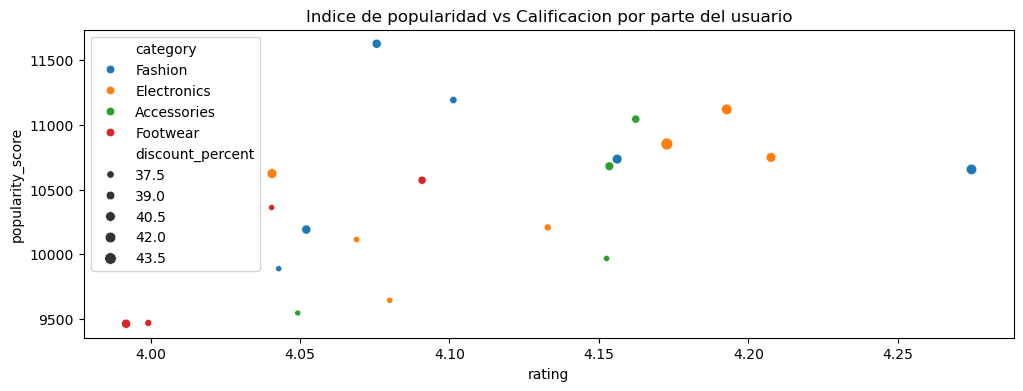

In [18]:
#Popularidad vs rating
plt.figure(figsize=(12,4))
sns.scatterplot(data=mas_popular, x='rating', y='popularity_score', hue='category', size='discount_percent')
plt.title('Indice de popularidad vs Calificacion por parte del usuario')
plt.show()

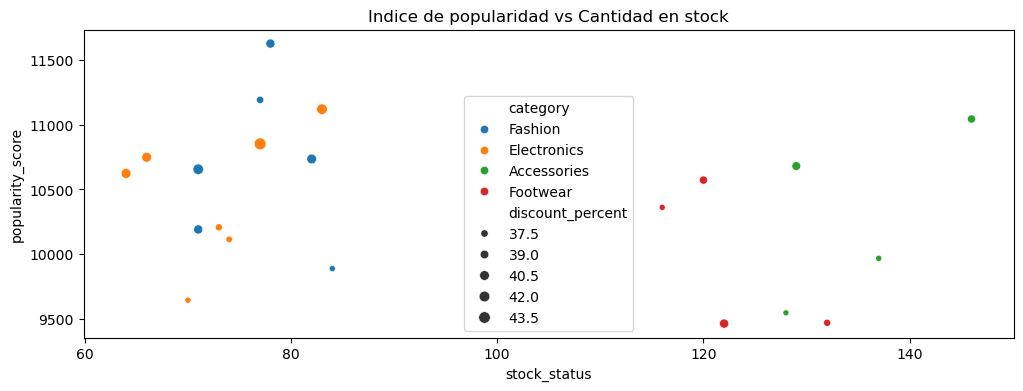

In [19]:
#Popularidad vs rating
plt.figure(figsize=(12,4))
sns.scatterplot(data=mas_popular, x='stock_status', y='popularity_score', hue='category', size='discount_percent')
plt.title('Indice de popularidad vs Cantidad en stock')
plt.show()

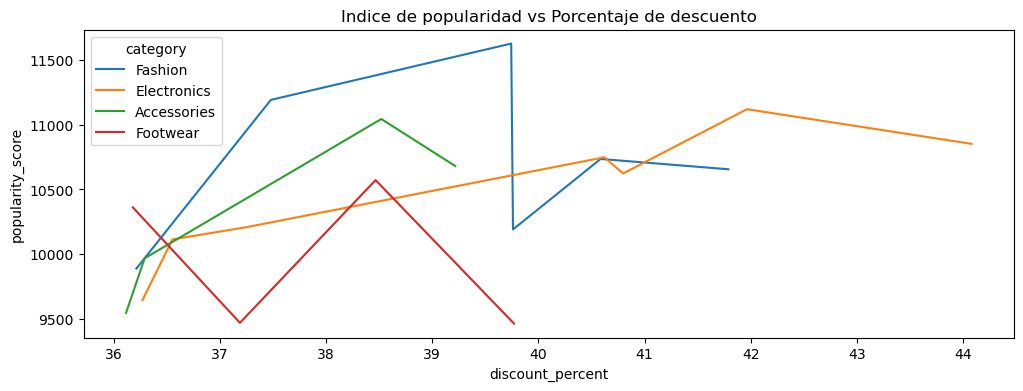

In [20]:
plt.figure(figsize=(12,4))
sns.lineplot(data=mas_popular, x='discount_percent', y='popularity_score', hue='category')
plt.title('Indice de popularidad vs Porcentaje de descuento')
plt.show()

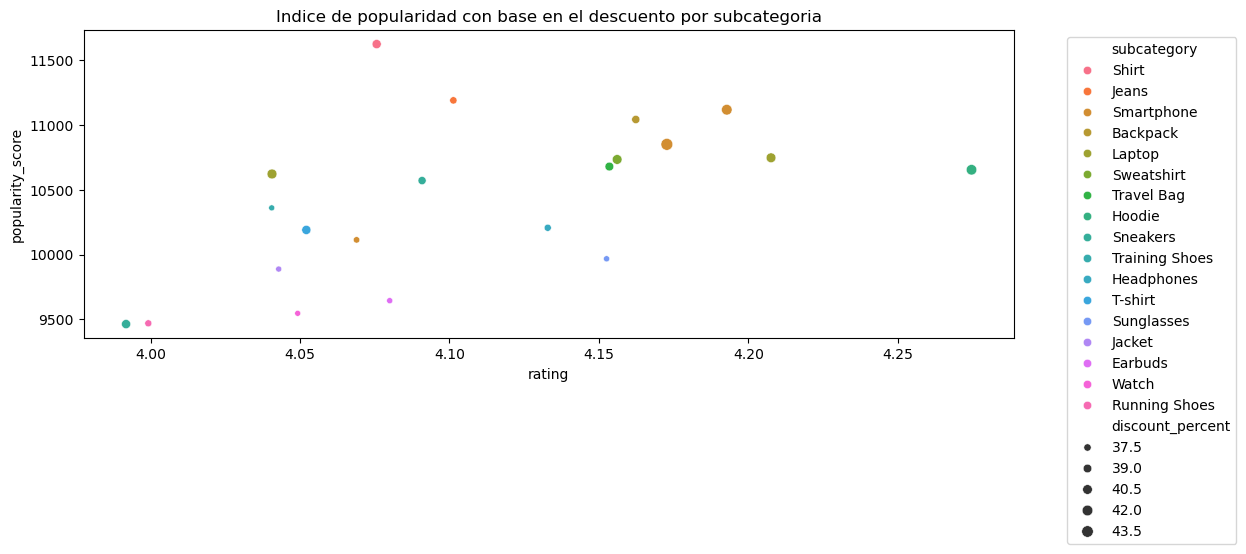

In [21]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=mas_popular, x='rating', y='popularity_score', hue='subcategory', size='discount_percent')
plt.title('Indice de popularidad con base en el descuento por subcategoria')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

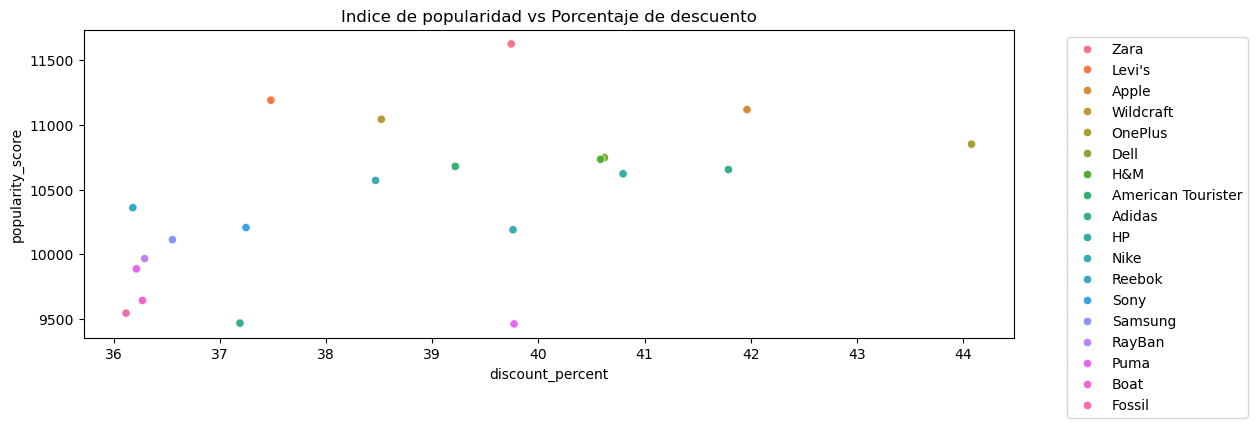

In [22]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=mas_popular, x='discount_percent', y='popularity_score', hue='brand')
plt.title('Indice de popularidad vs Porcentaje de descuento')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

In [23]:
#Reorganizamos en una pivot table para comparar por marca y subcategoria
pv3 = brands.pivot_table(values='popularity_score',
                         index='brand',
                         columns='category',
                         aggfunc='mean',
                         fill_value=0)
pv3.head()

category,Accessories,Electronics,Fashion,Footwear
brand,,,,
Adidas,0.000000,0.000000,10655.740845,9469.651515
American Tourister,10680.587597,0.000000,0.000000,0.000000
Apple,0.000000,11119.525301,0.000000,0.000000
Boat,0.000000,9644.560000,0.000000,0.000000
Dell,0.000000,10748.301515,0.000000,0.000000


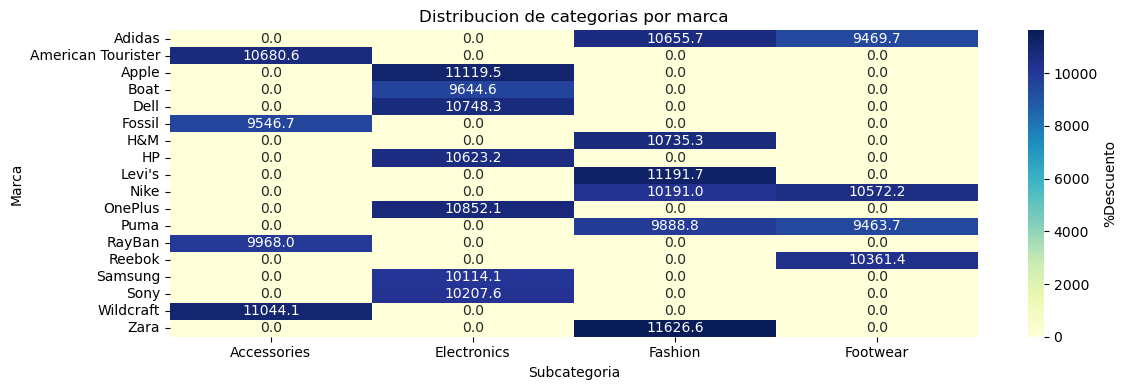

In [24]:
#Graficamos en un mapa de calor para conocer la distribucion por subcategoria con base en cada marca y conocer la relacion con el porcentaje de descuento
plt.figure(figsize=(12,4))
sns.heatmap(pv3, annot=True, fmt='.1f', cmap='YlGnBu',cbar_kws={'label':'%Descuento'})
plt.title('Distribucion de categorias por marca')
plt.ylabel('Marca')
plt.xlabel('Subcategoria')
plt.tight_layout()
plt.show()

In [25]:
#Agregamos la comparativa de categoria con marca y subcategorias
pv4 = brands.pivot_table(values='popularity_score',index='brand',columns='subcategory',aggfunc='mean',fill_value=0)
pv4.head()

subcategory,Backpack,Earbuds,Headphones,Hoodie,Jacket,Jeans,Laptop,Running Shoes,Shirt,Smartphone,Sneakers,Sunglasses,Sweatshirt,T-shirt,Training Shoes,Travel Bag,Watch
brand,,,,,,,,,,,,,,,,,
Adidas,0.0,0.00,0.0,10655.740845,0.0,0.0,0.000000,9469.651515,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
American Tourister,0.0,0.00,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,10680.587597,0.0
Apple,0.0,0.00,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,11119.525301,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
Boat,0.0,9644.56,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
Dell,0.0,0.00,0.0,0.000000,0.0,0.0,10748.301515,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


In [26]:
brands.head(2)

,product_name,brand,category,subcategory,price,currency,discount_percent,discounted_price,rating,reviews_count,popularity_score,stock_status,date_added,description
0,iPhone 13,Apple,Electronics,Smartphone,65372,INR,57,28109.96,3.7,3050,11285.0,Limited Stock,2025-10-17,Apple iPhone 13 is a premium smartphone design...
1,Zara Shirt,Zara,Fashion,Shirt,2616,INR,55,1177.20,4.1,4699,19265.9,Out of Stock,2026-03-22,Zara Zara Shirt is a premium shirt designed fo...


In [27]:
#Seleccionamos variables
x = brands[['brand','category','subcategory','price','currency','discount_percent','discounted_price','reviews_count','popularity_score',
           'stock_status', 'date_added']]
y = brands['rating']

In [28]:
#Aplicamos OHE,a los valores para poder procesarlos de forma numerica
OHE = pd.get_dummies(x, drop_first=True)
OHE.head()

,price,discount_percent,discounted_price,reviews_count,popularity_score,brand_American Tourister,brand_Apple,brand_Boat,brand_Dell,brand_Fossil,...,date_added_2026-04-22,date_added_2026-04-23,date_added_2026-04-24,date_added_2026-04-25,date_added_2026-04-26,date_added_2026-04-27,date_added_2026-04-28,date_added_2026-04-29,date_added_2026-04-30,date_added_2026-05-01
0,65372,57,28109.96,3050,11285.0,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2616,55,1177.20,4699,19265.9,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1305,58,548.10,1700,6120.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,7471,60,2988.40,860,3010.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1305,37,822.15,138,538.2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [29]:
#Normalizacion
scaler = MinMaxScaler()
x_scaled=scaler.fit_transform(OHE)

In [30]:
#Aplicamos segmentacion y agrupacion de valores con Kmeans
kMeans = KMeans(n_clusters=4, random_state=42)
OHE['cluster'] = kMeans.fit_predict(x_scaled)

In [31]:
OHE.head(2)

,price,discount_percent,discounted_price,reviews_count,popularity_score,brand_American Tourister,brand_Apple,brand_Boat,brand_Dell,brand_Fossil,...,date_added_2026-04-23,date_added_2026-04-24,date_added_2026-04-25,date_added_2026-04-26,date_added_2026-04-27,date_added_2026-04-28,date_added_2026-04-29,date_added_2026-04-30,date_added_2026-05-01,cluster
0,65372,57,28109.96,3050,11285.0,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,0
1,2616,55,1177.20,4699,19265.9,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,3


In [32]:
segmentacion = OHE.groupby('cluster')[['popularity_score','reviews_count','discount_percent']].mean()

In [33]:
segmentacion

,popularity_score,reviews_count,discount_percent
cluster,,,
0,10486.234122,2531.530572,39.708087
1,10329.312407,2490.181481,37.551852
2,9949.288980,2455.204082,37.906122
3,10712.106911,2610.630670,39.192225


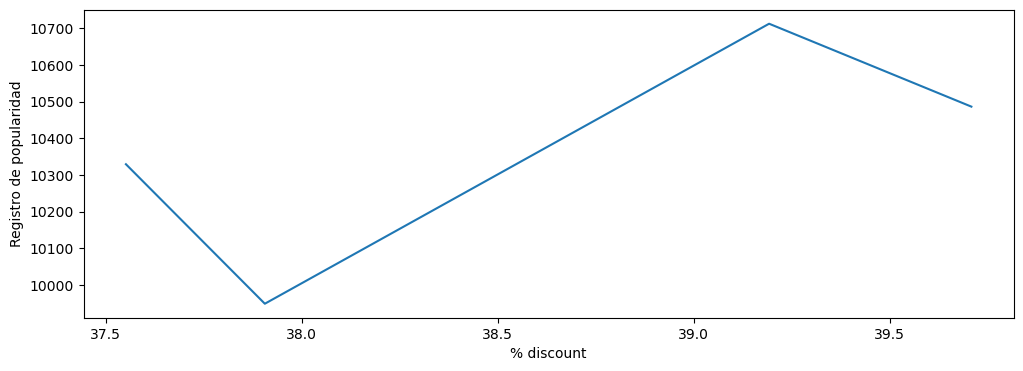

In [34]:
plt.figure(figsize=(12,4))
sns.lineplot(data=segmentacion, x='discount_percent', y='popularity_score')
plt.xlabel('% discount')
plt.ylabel('Registro de popularidad')
plt.show()

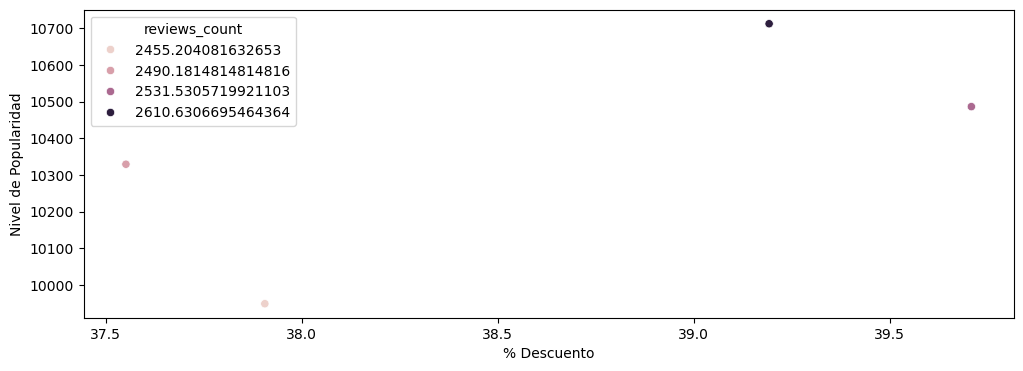

In [35]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=segmentacion, x='discount_percent', y='popularity_score', hue='reviews_count')
plt.xlabel('% Descuento')
plt.ylabel('Nivel de Popularidad')
plt.show()

#### Regresion Lineal

In [36]:
X = pd.get_dummies(x, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [37]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [38]:
y_pred = model.predict(X_test)

In [39]:
print('MSE:',mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test,y_pred))

MSE: 0.12691713445264163
R2: 0.5617397591414334


#### Aplicamos segmentacion con Kmeans, para conocer si podemos predecir los descuentos que pueden favorecer la demanda del producto y preferencia

In [40]:
X = brands[['discount_percent','reviews_count','popularity_score','rating']]

In [41]:
#Normalizacion
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
#segmentacion con Kmeans
kmeans = KMeans(n_clusters=4, random_state=42)
brands['cluster']=kmeans.fit_predict(X_scaled)
segmentacion = brands.groupby('cluster')[['discount_percent','reviews_count','popularity_score','rating']].mean()
segmentacion

,discount_percent,reviews_count,popularity_score,rating
cluster,,,,
0,54.554028,3750.223969,15700.382908,4.207466
1,22.169565,1203.413043,4781.387826,4.020000
2,21.797348,3651.446970,15037.313447,4.133333
3,54.980119,1291.367793,5166.146521,4.038370


In [43]:
#Seguir con aplicacion de Regresion Lineal
features = ['discount_percent','reviews_count','popularity_score']
X = brands [features]
y = brands ['rating']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

In [45]:
#Entrenamiento
modelLR = LinearRegression()
modelLR.fit(X_train,y_train)

LinearRegression()

In [47]:
y_pred = modelLR.predict(X_test)

In [48]:
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

MSE: 0.06874139249867113
R2: 0.7626276439083768


In [54]:
#Simulacion de escenarios
discounts = np.arange(0,55,5)
X_test = X_test.copy()
for d in discounts:
    X_test['discount_percent']= d
    pred=modelLR.predict(X_test[features])
    print(f'Descuento{d}% Rating promedio predicho {pred.mean():.2f}')

Descuento0% Rating promedio predicho 4.11
Descuento5% Rating promedio predicho 4.11
Descuento10% Rating promedio predicho 4.11
Descuento15% Rating promedio predicho 4.11
Descuento20% Rating promedio predicho 4.11
Descuento25% Rating promedio predicho 4.11
Descuento30% Rating promedio predicho 4.11
Descuento35% Rating promedio predicho 4.11
Descuento40% Rating promedio predicho 4.11
Descuento45% Rating promedio predicho 4.11
Descuento50% Rating promedio predicho 4.11


Conclusiones
Se observa que los resultados obtenidos sobre la prediccion en los montos de descuento, mantienen la calificacion de los clientes, sin embargo, se requeriria realizar mas pruebas con diferentes variables que ayuden a nutrir la prueba, ya que, puede ser que no sean suficientes para lograr entender el comportamiento con base en el porcentaje de descuento, incluyendo el precio, el monto descontado conforme a cada descuento ademas de la fecha de adquisicion lo cual aportaria informacion importante en la temporalidad de la adquisicion de los productos ayudando a entender mejor el comportamiento y su posible mejoria en el entendimiento de la prediccion asi como para lograr un mejor entendimiento hacia donde dirijir los desceuntos de forma mas agresiva